In [21]:
import numpy as np
import os
import astropy.units as u
import pandas as pd
from datetime import datetime, timedelta
from astropy.time import Time
import re
from sunpy.coordinates import sun
import helio_coords as hcoords

import matplotlib.animation as animation
import matplotlib.pyplot as plt
import matplotlib as mpl

import joblib
import onnxruntime as ort

import huxt as H
import huxt_inputs as Hin
import huxt_analysis as HA

In [22]:
# Function to convert a date string to a datetime object
def convert_to_datetime(date_str):
    # List of possible date formats
    date_formats = [
        '%Y-%m-%d %H:%M:%S',
        '%Y/%m/%d %H%M',
        '%Y/%m/%d %H%M(%S)',
        '%Y/%m/%d %H%M(S)',
        '%Y/%m/%d %H:%M',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d %H:%M(S)',
        '%d/%m/%Y %H:%M'
    ]
    for date_format in date_formats:
        try:
            return datetime.strptime(date_str, date_format)
        except ValueError:
            continue
    # If no format matches, return None
    return None
    
# Function to convert Time_Error from string to timedelta
def convert_to_timedelta(time_str):
    try:
        return pd.to_timedelta(time_str)
    except ValueError:
        return None

# Function to get earth's latitude
def get_earth_lat(dt):
    """
    A function to return Earth latitude for a given date, in radians
 
    Parameters
    ----------
    dt : datetime
 
    Returns
    -------
    E_lat: Earth latitude, with astropy units of radians
 
    """
    cr, cr_lon_init = Hin.datetime2huxtinputs(dt)
    
    # Use the HUXt ephemeris data to get Earth lat over the CR
    # ========================================================
    dummymodel = H.HUXt(v_boundary=np.ones(128)*400*(u.km/u.s), simtime=0.1*u.day,
                         cr_num=cr,cr_lon_init=cr_lon_init, lon_out=0.0*u.deg)
    # retrieve a bodies position at each model timestep:
    earth = dummymodel.get_observer('earth')
    # get average Earth lat
    E_lat = np.nanmean(earth.lat_c)
    E_lat = E_lat.to(u.deg)  # Convert to degrees
    return E_lat

def earth_R(mjd):
    #returns the heliocentric distance of Earth (in km). Based on Franz+Harper2002
    AU = 149597870.691
    
    #first up, switch to JD.
    JD=mjd+2400000.5
    d0=JD-2451545
    T0=d0/36525


    L2=100.4664568 + 35999.3728565*T0
    g2=L2-(102.9373481+0.3225654*T0)
    g2=g2*np.pi/180 #mean anomaly

    rAU=1.00014 - 0.01671*np.cos(g2)-0.00014*np.cos(2*g2);
    R=rAU*AU
    
    return R

In [23]:
def plot_huxt_multi(ax, time, model):
    """
    Plot the HUXt solution at a specified time, and (optionally) overlay the modelled flank location and field of view
    of a specified observer.
    :param ax: Axes handle to plot in.
    :param time: The time to plot. The closest value in model.time_out is selected.
    :param model: A HUXt instance with the solution in.
    :return:
    """
    id_t = np.argmin(np.abs(model.time_out - time))

    # Get plotting data
    lon_arr, dlon, nlon = H.longitude_grid()
    lon, rad = np.meshgrid(lon_arr.value, model.r.value)
    mymap = mpl.cm.viridis
    v_sub = model.v_grid.value[id_t, :, :].copy()
    # Insert into full array
    if lon_arr.size != model.lon.size:
        v = np.zeros((model.nr, nlon)) * np.NaN
        if model.lon.size != 1:
            for i, lo in enumerate(model.lon):
                id_match = np.argwhere(lon_arr == lo)[0][0]
                v[:, id_match] = v_sub[:, i]
        else:
            print('Warning: Trying to contour single radial solution will fail.')
    else:
        v = v_sub

    # Pad out to fill the full 2pi of contouring
    pad = lon[:, 0].reshape((lon.shape[0], 1)) + model.twopi
    lon = np.concatenate((lon, pad), axis=1)
    pad = rad[:, 0].reshape((rad.shape[0], 1))
    rad = np.concatenate((rad, pad), axis=1)
    pad = v[:, 0].reshape((v.shape[0], 1))
    v = np.concatenate((v, pad), axis=1)

    # Create a filled contour plot with custom over/under colours, fixed contour levels
    mymap.set_over('lightgrey')
    mymap.set_under([0, 0, 0])
    levels = np.arange(200, 800 + 10, 10)
    cnt = ax.contourf(lon, rad, v, levels=levels, cmap=mymap, extend='both')
    # Remove edgelines that appear in pdfs
    for c in cnt.collections:
        c.set_edgecolor("face")

    # Plot each CME’s radial profile in longitude–radius space using a rotating colour cycle; 
    # close each profile by appending the first point
    cme_colors = ['r', 'c', 'm', 'y', 'deeppink', 'darkorange']
    for j, cme in enumerate(model.cmes):
        cid = np.mod(j, len(cme_colors))
        cme_lons = cme.coords[id_t]['lon']
        cme_r = cme.coords[id_t]['r'].to(u.solRad)
        if np.any(np.isfinite(cme_r)):
            # Pad out to close the profile.
            cme_lons = np.append(cme_lons, cme_lons[0])
            cme_r = np.append(cme_r, cme_r[0])
            ax.plot(cme_lons, cme_r, '-', color=cme_colors[cid], linewidth=3)

    # Set axes customisations
    ax.set_ylim(0, model.r.value.max())
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.patch.set_facecolor('slategrey')
    return id_t

In [24]:
# Read in Met Office Cone CME files
project_dirs = H._setup_dirs_()
crpath = os.path.join(project_dirs['input'],'(I)CMEs.csv')

# Load the CSV file into a DataFrame
crlist = pd.read_csv(crpath)

# Convert date columns to datetime objects using datetime library
date_columns = ['Time_21.5', 'Disturbance_Time']
for column in date_columns:
    crlist[column] = crlist[column].apply(lambda x: convert_to_datetime(x) if isinstance(x, str) else None)

# compute 21.5-215 transit time
crlist['tt_21'] = np.nan 
for irow in range(0, len(crlist)):
    crlist.loc[irow,'tt_21'] = crlist.loc[irow,'Disturbance_Time'] - crlist.loc[irow,'Time_21.5']
# Convert  from timedelta to days
crlist['tt_21'] = crlist['tt_21'].apply(lambda x: x.days + x.seconds / 86400 if isinstance(x, timedelta) else None)

# Add a new column with carrington rotation number of CME time
crlist['cr_num'] = crlist['Time_21.5'].apply(lambda dt: Hin.datetime2huxtinputs(dt)[0])
crlist['cr_lon_init'] = crlist['Time_21.5'].apply(lambda dt: Hin.datetime2huxtinputs(dt)[1])
crlist['earth_lat'] = crlist['Time_21.5'].apply(lambda dt: get_earth_lat(dt))

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_2965/2884343979.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2 days 05:50:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  crlist.loc[irow,'tt_21'] = crlist.loc[irow,'Disturbance_Time'] - crlist.loc[irow,'Time_21.5']


In [25]:
# --- Load ICME  ---------------------------------------------------------------

icmelist_path = os.path.join(project_dirs['input'],
                                'Richardson_Cane_Processed_ICME_list.csv')

#HUXt run parameters
dt_scale = 4
rmin = 21.5*u.solRad
rmax = 230*u.solRad #outer boundary for HUXt runs

recon_noicmes = True #whether to remove ICMEs
icme_list = 'CaneRichardson'#'DONKI'
pre_icme_buffer = 0.2 #days
post_icme_buffer = 1 #days
sw_buffer = 2*u.day #window over which to average to fill in the solar wind during ICMEs

#fill values for ICME removal if interpolation isn't possible
vsw_fill = 450 *u.km/u.s
bx_fill = 0

In [26]:
def ICMElist(filepath):
    # -*- coding: utf-8 -*-
    """
    A script to read and process Ian Richardson's ICME list.

    Some pre-processing is required:
        Download the following webpage as a html file: 
            http://www.srl.caltech.edu/ACE/ASC/DATA/level3/icmetable2.htm
        Open in Excel, remove the year rows, delete last column (S) which is empty
        Cut out the data table only (delete header and footer)
        Save as a CSV.

    """
    
    icmes=pd.read_csv(filepath,header=None)
    #delete the first row
    icmes.drop(icmes.index[0], inplace=True)
    icmes.index = range(len(icmes))
    
    for rownum in range(0,len(icmes)):
        for colnum in range(0,3):
            #convert the three date stamps
            datestr=icmes[colnum][rownum]
            year=int(datestr[:4])
            month=int(datestr[5:7])
            day=int(datestr[8:10])
            hour=int(datestr[11:13])
            minute=int(datestr[13:15])
            #icmes.set_value(rownum,colnum,datetime(year,month, day,hour,minute,0))
            icmes.at[rownum,colnum] = datetime(year,month, day,hour,minute,0)
            
            #print(datestr)
            
        #tidy up the plasma properties
        for paramno in range(10,17):
            dv=str(icmes[paramno][rownum])
            
            #print(str(paramno)+ ' ' + dv)
            
            if dv == '...' or dv == 'dg' or dv == 'nan' or dv == '... P' or dv == '... Q':
                #icmes.set_value(rownum,paramno,np.nan)
                icmes.at[rownum,paramno] = np.nan
            else:
                #remove any remaining non-numeric characters
                dv=re.sub('[^0-9]','', dv)
                #icmes.set_value(rownum,paramno,float(dv))
                icmes.at[rownum,paramno] = float(dv)
        
    
    #chage teh column headings
    icmes=icmes.rename(columns = {0:'Shock_time',
                                  1:'ICME_start',
                                  2:'ICME_end',
                                  10:'dV',
                                  11: 'V_mean',
                                  12:'V_max',
                                  13:'Bmag',
                                  14:'MCflag',
                                  15:'Dst',
                                  16:'V_transit'})
    return icmes
  


In [27]:
# --- Remove ICME and backmap OMNI solution to 21.5 solRad ----------------------
def correct_inner_vlon_cnn_onnx(v_inner_array,
                                data_dir=os.path.join(project_dirs['input'])):
    """
    Corrects solar wind speed as a function of longitude using a 1D CNN model
    trained to account for stream interactions during backmapping from 1 AU 
    to 0.1 AU. Uses ONNX, rather than pytorch.

    Parameters:
    - v_inner_array: np.ndarray of shape (128, N) [speed vs. longitude & samples]
    - data_dir: directory containing saved scalers and ONNX model

    Returns:
    - Y_pred: np.ndarray of shape (128, N), CNN-corrected speed
    """

    # Load scalers
    y_scaler = joblib.load(os.path.join(data_dir, 'y_scaler_torch.save'))
    x_scaler = joblib.load(os.path.join(data_dir, 'x_scaler_torch.save'))

    # Transpose input to shape (N, 128) so each row is a sample
    vcarr_scaled = x_scaler.transform(v_inner_array.T)  # (N, 128)

    # Reshape to ONNX expected input: (batch_size, channels=1, length=128)
    X_input = vcarr_scaled[:, np.newaxis, :].astype(np.float32)  # (N, 1, 128)

    # Load ONNX model
    onnx_path = os.path.join(data_dir, 'CNN_model.onnx')
    ort_session = ort.InferenceSession(onnx_path)

    # Run inference
    input_name = ort_session.get_inputs()[0].name
    output = ort_session.run(None, {input_name: X_input})
    Y_pred_scaled = output[0]  # (N, 1, 128)

    # Postprocess: squeeze to (N, 128)
    Y_pred_scaled = Y_pred_scaled.squeeze(1)

    # Inverse transform
    Y_pred = y_scaler.inverse_transform(Y_pred_scaled)  # (N, 128)

    # Transpose back to (128, N) to match input shape
    return Y_pred.T

In [28]:
def preprocess_omni(cme):
    '''Download OMNI data and produce boundary conditions for a given CME'''
    
    # Download and process OMNI
    icme_time = cme['Time_21.5']
    print(icme_time)
    
    # Compute the run start and end times so that the ICME is at the end of the window

    simtime = 27.27 * u.day
    dl_starttime = icme_time - timedelta(days=28)
    dl_endtime = icme_time
    omni = Hin.get_omni(dl_starttime, dl_endtime)
        
    # Remove ICME from OMNI
    if recon_noicmes:
    
        #create a copy of the OMNI data for ICME removal, before any end padding
        omni_noicmes = omni.copy()
        #load the DONKI ICME list
        if icme_list == 'DONKI':
            icmes = Hin.get_DONKI_ICMEs(dl_starttime, dl_endtime)
        elif icme_list == 'CaneRichardson':
            icmes = ICMElist(icmelist_path)
    
        #remove all ICMEs
        params = ['V', 'BX_GSE']
        # first remove all ICMEs and add NaNs to the required parameters
        icmes['shock_mjd'] = Time(icmes['Shock_time'].to_numpy()).mjd
        icmes['end_mjd'] = Time(icmes['ICME_end'].to_numpy()).mjd
    
        for i in range(0, len(icmes)):

            icme_start = icmes['shock_mjd'][i] - pre_icme_buffer
            icme_stop = icmes['end_mjd'][i] + post_icme_buffer 
            
            mask_icme = ((omni_noicmes['mjd'] >= icme_start) &
                         (omni_noicmes['mjd'] <= icme_stop))
            
            if any(mask_icme):
                print('removing ICME #' + str(i))
                for param in params:
                    omni_noicmes.loc[mask_icme, param] = np.nan


        #now interp through all datagaps
        omni_noicmes = omni_noicmes.set_index('datetime')
        omni_noicmes[['V', 'BX_GSE']] = omni_noicmes[['V', 'BX_GSE']].interpolate(method='time').ffill().bfill()
        omni_noicmes = omni_noicmes.reset_index()
        
    #add the carrington longitude to the omni data
    def remainder(cr_frac):
        if np.isscalar(cr_frac):
            return int(np.floor(cr_frac))
        else:
            return np.floor(cr_frac).astype(int)
    cr_frac = sun.carrington_rotation_number(omni_noicmes['datetime'])
    cr = remainder(cr_frac)
    omni_noicmes['lon_carr'] = 2 * np.pi * (1 - (cr_frac - cr))    
    
    #create vCarr  with the omni time series at 1 AU
    #======================================================
    
    #unwrap the carr long
    unwrapped = np.unwrap(omni_noicmes['lon_carr'], discont=np.pi)
    #find the current value
    idx = np.argmin(np.abs(omni_noicmes['datetime'] - icme_time))
    curr_lon = unwrapped[idx]
    #find the data up to 2 pi previously 
    mask = ((unwrapped < curr_lon + 2*np.pi) & (unwrapped >= curr_lon))
    omni_chunk = omni_noicmes.loc[mask].reset_index(drop=True)
    
    #sort by carrington lon
    omni_lon = omni_chunk.sort_values(by='lon_carr').reset_index(drop=True)
    
    #now map back to the inner boundary
    Earth_R_km = hcoords.earth_R(Time(icme_time).mjd) *u.km
    vcarr_rmin_back = Hin.map_v_boundary_inwards(omni_lon['V'].to_numpy()*u.km/u.s,
                                    Earth_R_km.to(u.solRad), rmin)
    
    #interp to typical HUXt resolution
    dphi = 2*np.pi/H.huxt_constants()['nlong']
    longs = np.arange(dphi/2, 2*np.pi, dphi)
    vlon = np.interp(longs, omni_lon['lon_carr'], vcarr_rmin_back)
    
    # apply the CNN to the backmapped data
    vcarr_rmin_back_cnn = correct_inner_vlon_cnn_onnx(vlon.reshape(-1, 1))
                                    
    return simtime, vcarr_rmin_back_cnn, icme_time

In [29]:
print(crlist.iloc[24,:])

Time_21.5              2024-01-20 09:24:00
Disturbance_Time       2024-01-22 16:01:00
CME_V                                  944
lon                                    -20
lat                                    -15
Ang_rad                                 40
V_max                                462.0
V_max_smooth                        442.25
tt_21                             2.275694
cr_num                                2280
cr_lon_init          5.795384674670971 rad
earth_lat           -5.016283606151297 deg
Name: 24, dtype: object


In [30]:
#========================================================
# Obtain OMNI boundary conditions at 21.5 rS
onecme = crlist.iloc[2,:]
simtime, vcarr_rmin_back_cnn, run_start = preprocess_omni(onecme)

# Obtain MAS boundary conditions at 21.5 rS
vr_in = Hin.get_MAS_long_profile(onecme['cr_num'], onecme['earth_lat'])
vr_MAS = Hin.map_v_boundary_inwards(vr_in, 30*u.solRad, rmin)

# Obtain WSA boundary conditions at 21.5 rS
wsafilepath = os.path.join(os.path.join("/Users/dven/repos/CME_pulse_duration/huxt/data/input/wsa_gong_2023022400.fits"))
v_in = Hin.get_WSA_long_profile(wsafilepath, lat=0.0 * u.deg)
vr_WSA = Hin.map_v_boundary_inwards(v_in, 30*u.solRad, rmin)
    
cr, cr_lon_init = Hin.datetime2huxtinputs(run_start)
    
#========================================================
# Set up the model at 21.5 rS with backmapped OMNI
    
ten_model = H.HUXt(v_boundary = vcarr_rmin_back_cnn.flatten() * u.km/u.s, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = simtime, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

twenty_model = H.HUXt(v_boundary = vcarr_rmin_back_cnn.flatten() * u.km/u.s, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = simtime, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

five_model = H.HUXt(v_boundary = vcarr_rmin_back_cnn.flatten() * u.km/u.s, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = simtime, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

sph_model = H.HUXt(v_boundary = vcarr_rmin_back_cnn.flatten() * u.km/u.s, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = simtime, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

bg_model = H.HUXt(v_boundary = vcarr_rmin_back_cnn.flatten() * u.km/u.s, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = simtime, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

#========================================================
# Set up the model at 21.5 rS with backmapped MAS
    
MAS_ten_model = H.HUXt(v_boundary = vr_MAS, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = simtime, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

MAS_sph_model = H.HUXt(v_boundary = vr_MAS, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = simtime, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

MAS_bg_model = H.HUXt(v_boundary = vr_MAS, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = simtime, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

#========================================================
# Set up the model at 21.5 rS with WSA
    
WSA_ten_model = H.HUXt(v_boundary = vr_WSA, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = simtime, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

WSA_sph_model = H.HUXt(v_boundary = vr_WSA, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = simtime, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)

WSA_bg_model = H.HUXt(v_boundary = vr_WSA, cr_num = cr, cr_lon_init = cr_lon_init,
                            simtime = simtime, r_min=rmin, r_max=rmax, dt_scale=dt_scale, latitude=0*u.deg, frame = 'synodic', 
                            track_cmes = True)
    
#========================================================
# Cone cmes
'''Solve HUXt using a fixed pulse duration cone CME'''
    
ten_cme = H.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad, cme_fixed_duration=True,
                fixed_duration=10.0 * 60 * 60 * u.s)

twenty_cme = H.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad, cme_fixed_duration=True,
                fixed_duration=22.0 * 60 * 60 * u.s)

five_cme = H.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad, cme_fixed_duration=True,
                fixed_duration=5.0 * 60 * 60 * u.s)

sph_cme = H.ConeCME(t_launch=0.0 * u.day, longitude=onecme['lon'] * u.deg, latitude=onecme['lat'] * u.deg,
                initial_height=rmin, width=2.0 * onecme['Ang_rad'] * u.deg, v=onecme['CME_V'] * (u.km / u.s),
                thickness=0.0 * u.solRad,
                cme_fixed_duration=False)

ten_model.solve([ten_cme])
MAS_ten_model.solve([ten_cme])
WSA_ten_model.solve([ten_cme])

twenty_model.solve([twenty_cme])
five_model.solve([five_cme])

sph_model.solve([sph_cme])
MAS_sph_model.solve([sph_cme])
WSA_sph_model.solve([sph_cme])

bg_model.solve([])
MAS_bg_model.solve([])
WSA_bg_model.solve([])

2023-03-13 10:53:00


Files Downloaded: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  6.59file/s]


removing ICME #550
removing ICME #551
removing ICME #552
removing ICME #553
removing ICME #554
removing ICME #555
HDF5 files already exist for CR2268


/opt/miniconda3/envs/huxt/lib/python3.9/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_2965/1472319774.py:43: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in cnt.collections:
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_2965/1472319774.py:43: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in cnt.collections:
/opt/miniconda3/envs/huxt/lib/python3.9/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_2965/1472319774.py:43: MatplotlibDeprecationWarning: The collec

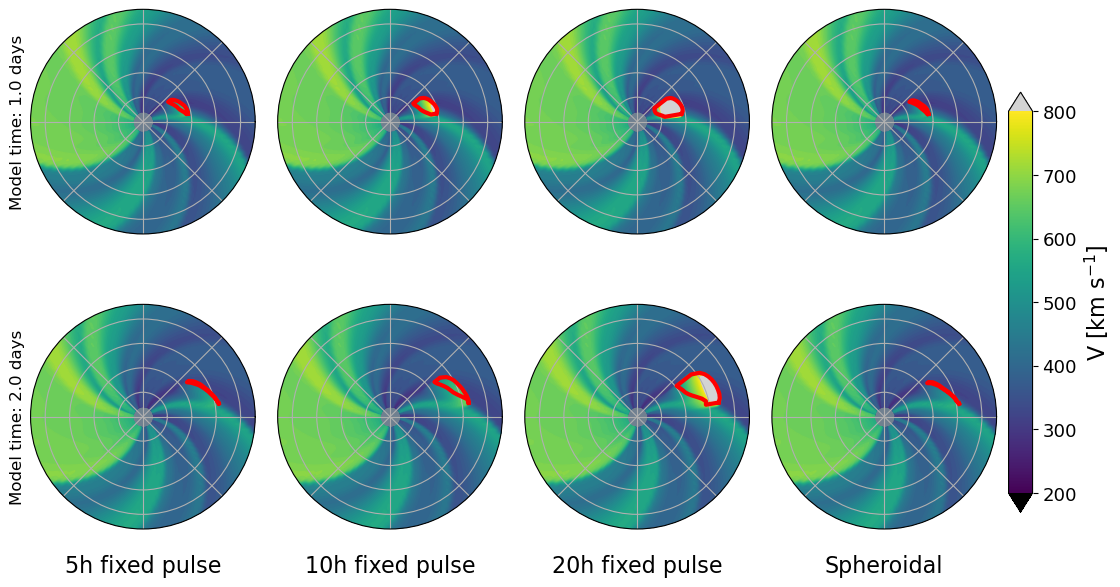

In [31]:
def plot_2D_example():
    
    # Create a 2×4 grid of polar subplots for comparing two phases at three time stamps
    fig, ax = plt.subplots(2, 4, figsize=(12, 6), subplot_kw={"projection": "polar"})

    # Define the two solar-cycle models and their labels
    models = [five_model, ten_model, twenty_model, sph_model]
    labels = ["5h fixed pulse", "10h fixed pulse", "20h fixed pulse", "Spheroidal"]

    # Loop over models and plot CME evolution for multiple times
    for col, (model, label) in enumerate(zip(models, labels)):
        cme = model.cmes[0]
        stats = cme.compute_arrival_at_body('Earth')
        hit_id = stats['hit_id']
        halfway_id = np.int64(np.fix(hit_id / 2.0))

        # Plot at 1, 2, and 3 days for each model
        for row, time_out in enumerate([1 * u.day, 2 * u.day]):
            id_t = plot_huxt_multi(ax[row, col], time_out, model)

            # Add annotation showing the model time corresponding to the plotted state
            time_label = "Model time: {:3.1f} days".format(model.time_out[id_t].to(u.day).value)
            ax[row, 0].set_ylabel(time_label, fontsize=12)    
            
        # Label the left column with the model description
        ax[1, col].set_xlabel(label, fontsize=16)

    # Adjust figure spacing to fit colourbar and subplot content cleanly
    fig.subplots_adjust(left=0.075, bottom=0.12, right=0.88, top=0.99, wspace=0.1, hspace=0.3)

    # Configure colourmap and normalisation for the velocity colour scale
    mymap = mpl.cm.viridis
    mymap.set_over('lightgrey')
    mymap.set_under([0, 0, 0])
    norm = mpl.colors.Normalize(vmin=200, vmax=800)
    smp = mpl.cm.ScalarMappable(norm=norm, cmap=mymap)

    # Add a vertical colorbar to the right of the subplot grid
    cbaxes = fig.add_axes([0.89, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(smp, cax=cbaxes, orientation='vertical', extend='both')
    cbar.ax.tick_params(labelsize=13)
    cbar.set_label('V [km s$^{-1}$]')

    # Add legends to each subplot for CME boundaries and solar-wind structures
    for row in range(2):
        for col in range(4):
            ax[row, col].legend(bbox_to_anchor=(0.5, -0.1), loc="center", ncol=3, frameon=False, handletextpad=0.0, columnspacing=0.0)

    fig.savefig("/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/2d_pulse_example.pdf", dpi=300, bbox_inches='tight')

plot_2D_example()

ValueError: longitude and radius must be single values or be arrays of length equal to the number of time steps

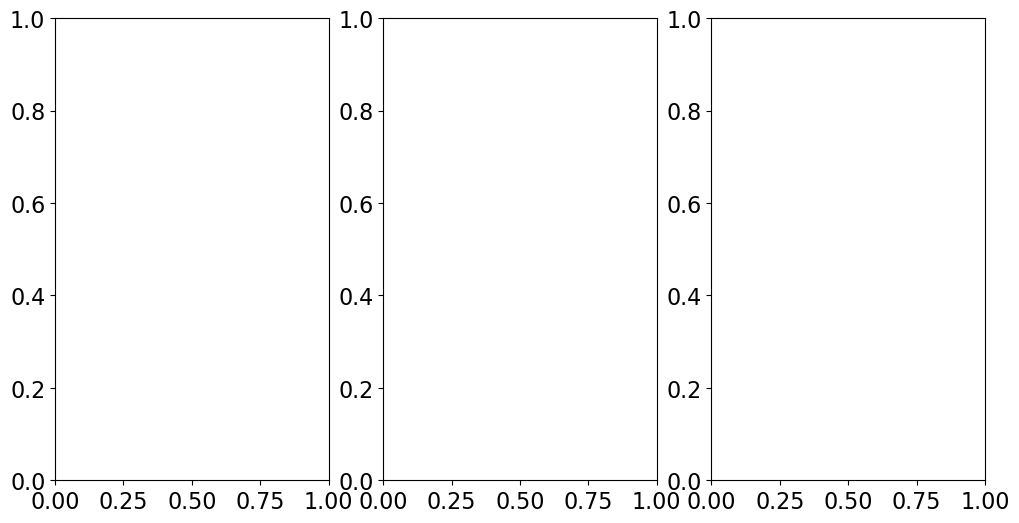

In [32]:
def plot_earth_timeseries(eleven_model, sph_model, bg_model, plot_omni=True):
    """
    A function to plot the HUXt Earth time series. With option to download and plot OMNI data.
    Args:
        model : input model class
        plot_omni: Boolean, if True downloads and plots OMNI data

    Returns:
        fig : Figure handle
        axs : Axes handles

    """

    eleven_ts = HA.get_observer_timeseries(eleven_model, observer='Earth')
    sph_ts = HA.get_observer_timeseries(sph_model, observer='Earth')
    bg_ts = HA.get_observer_timeseries(bg_model, observer='Earth')
    
    eleven_cme_out = eleven_model.cmes[0]
    sph_cme_out = sph_model.cmes[0]
    
    eleven_stats = eleven_cme_out.compute_arrival_at_location(0.0 * u.rad, 215.0 * u.solRad)
    sph_stats = sph_cme_out.compute_arrival_at_location(0.0 * u.rad, 215.0 * u.solRad)
    
    eleven_hit = eleven_stats['hit']
    sph_hit = sph_stats['hit']
    
    if eleven_hit == 1:
        eleven_t_arrive = eleven_stats['t_arrive'].value
        sph_t_arrive = sph_stats['t_arrive'].value
        eleven_t_arrive = Time(eleven_t_arrive, format='jd', scale='utc')
        sph_t_arrive = Time(sph_t_arrive, format='jd', scale='utc')

    # 2-panel plot if the B polarity has been traced
    if hasattr(bg_model, 'b_grid'):
        fig, axs = plt.subplots(2, 1, figsize=(14, 7))
        axs[1].plot(huxt_ts['time'], np.sign(huxt_ts['bpol']), 'k.', label='HUXt')
        axs[1].set_ylabel('B polarity')
    else:
        fig, axs = plt.subplots(1, 1, figsize=(14, 4))
        axs = np.array([axs])

    axs[0].plot(eleven_ts['time'], eleven_ts['vsw'], 'c', label='11h Fixed Pulse')
    axs[0].plot(sph_ts['time'], sph_ts['vsw'], 'k', label='Spheroidal')
    axs[0].plot(bg_ts['time'], bg_ts['vsw'], 'k', linestyle='dotted', label='No CME')
    if  eleven_hit == 1:
        axs[0].axvline(sph_t_arrive.datetime,color='k')
        axs[0].axvline(eleven_t_arrive.datetime,color='c')
    axs[0].set_ylim(250, 1000)

    starttime = eleven_ts['time'][0]
    endtime = eleven_ts['time'][(len(eleven_ts)/2)-0.5]

    if plot_omni:
        # grab the omni data
        data = Hin.get_omni(starttime, endtime)
        # plot the period of interest
        mask = (data['datetime'] >= starttime) & (data['datetime'] <= endtime)
        plotdata = data[mask]
        axs[0].plot(plotdata['datetime'], plotdata['V'], 'r', label='OMNI')

        if hasattr(bg_model, 'b_grid'):
            axs[1].plot(plotdata['datetime'], -np.sign(plotdata['BX_GSE']) * 0.92, 'r.', label='OMNI')
            axs[1].set_ylim(-1.1, 1.1)

    for a in axs:
        a.set_xlim(starttime, endtime)
        a.legend()

    axs[0].set_ylabel('Solar Wind Speed (km/s)')

    if axs.size == 1:
        axs[0].set_xlabel('Date')
    elif axs.size == 2:
        axs[0].set_xticklabels([])
        axs[1].set_xlabel('Date')

    fig.subplots_adjust(left=0.07, bottom=0.08, right=0.99, top=0.97, hspace=0.05)

    return fig, axs

def plot_time_series():

    fig, axs = plt.subplots(3, 1, figsize=(12, 6))

    fig, axs[0] = plot_earth_timeseries(ten_model, sph_model, bg_model, plot_omni = True)
    axs[0].axvline(onecme['Disturbance_Time'], color='r')

    fig, axs[1] = plot_earth_timeseries(MAS_ten_model, MAS_sph_model, MAS_bg_model, plot_omni = True)
    axs[1].axvline(onecme['Disturbance_Time'], color='r')

    fig, axs[2] = plot_earth_timeseries(WSA_ten_model, WSA_sph_model, WSA_bg_model, plot_omni = True)
    axs[2].axvline(onecme['Disturbance_Time'], color='r')
    
    fig.savefig("/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/time_series_pulse_example.pdf", dpi=300, bbox_inches='tight')

plot_time_series()